# Introduction to PANDAS

## Documentation: https://pandas.pydata.org/docs/user_guide/index.html#user-guide
### Goals
- Reading some common file formats (.csv)
- Plotting time series for a given variable
- Do some operations on the data

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

## Reading a csv file
Let's read a .csv file. It contains hourly data of temperature, humitity, wind speed, visibility etc...
 

In [2]:
weather = pd.read_csv('./Datasets/weather_dataset.csv')
weather

,Date/Time,Temp_C,Dew Point Temp_C,Rel Hum_%,Wind Speed_km/h,Visibility_km,Press_kPa,Weather
0,1/1/2012 0:00,-1.8,-3.9,86,4,8.0,101.24,Fog
1,1/1/2012 1:00,-1.8,-3.7,87,4,8.0,101.24,Fog
2,1/1/2012 2:00,-1.8,-3.4,89,7,4.0,101.26,"Freezing Drizzle,Fog"
3,1/1/2012 3:00,-1.5,-3.2,88,6,4.0,101.27,"Freezing Drizzle,Fog"
4,1/1/2012 4:00,-1.5,-3.3,88,7,4.8,101.23,Fog
...,...,...,...,...,...,...,...,...
8779,12/31/2012 19:00,0.1,-2.7,81,30,9.7,100.13,Snow
8780,12/31/2012 20:00,0.2,-2.4,83,24,9.7,100.03,Snow
8781,12/31/2012 21:00,-0.5,-1.5,93,28,4.8,99.95,Snow
8782,12/31/2012 22:00,-0.2,-1.8,89,28,9.7,99.91,Snow


In [3]:
# Changing the date indexation of the table
weather['Date'] = pd.to_datetime(weather['Date/Time']) #Copy Date/Time column in a new entry 
weather = weather.set_index(weather.Date) #Use 'Date' entry as the the index column used to sort the others.
weather

,Date/Time,Temp_C,Dew Point Temp_C,Rel Hum_%,Wind Speed_km/h,Visibility_km,Press_kPa,Weather,Date
Date,,,,,,,,,
2012-01-01 00:00:00,1/1/2012 0:00,-1.8,-3.9,86,4,8.0,101.24,Fog,2012-01-01 00:00:00
2012-01-01 01:00:00,1/1/2012 1:00,-1.8,-3.7,87,4,8.0,101.24,Fog,2012-01-01 01:00:00
2012-01-01 02:00:00,1/1/2012 2:00,-1.8,-3.4,89,7,4.0,101.26,"Freezing Drizzle,Fog",2012-01-01 02:00:00
2012-01-01 03:00:00,1/1/2012 3:00,-1.5,-3.2,88,6,4.0,101.27,"Freezing Drizzle,Fog",2012-01-01 03:00:00
2012-01-01 04:00:00,1/1/2012 4:00,-1.5,-3.3,88,7,4.8,101.23,Fog,2012-01-01 04:00:00
...,...,...,...,...,...,...,...,...,...
2012-12-31 19:00:00,12/31/2012 19:00,0.1,-2.7,81,30,9.7,100.13,Snow,2012-12-31 19:00:00
2012-12-31 20:00:00,12/31/2012 20:00,0.2,-2.4,83,24,9.7,100.03,Snow,2012-12-31 20:00:00
2012-12-31 21:00:00,12/31/2012 21:00,-0.5,-1.5,93,28,4.8,99.95,Snow,2012-12-31 21:00:00


### Calling and printing a quantity
We can call a column directly by its name.

In [4]:
print(weather.Temp_C) # weater['Temp_C'] works too 
# To only get the data list, add a .values
print('')
print('Data list only:')
print(weather.Temp_C.values)

Date
2012-01-01 00:00:00   -1.8
2012-01-01 01:00:00   -1.8
2012-01-01 02:00:00   -1.8
2012-01-01 03:00:00   -1.5
2012-01-01 04:00:00   -1.5
                      ... 
2012-12-31 19:00:00    0.1
2012-12-31 20:00:00    0.2
2012-12-31 21:00:00   -0.5
2012-12-31 22:00:00   -0.2
2012-12-31 23:00:00    0.0
Name: Temp_C, Length: 8784, dtype: float64

Data list only:
[-1.8 -1.8 -1.8 ... -0.5 -0.2  0. ]


# Time series

The quantities are indexed by date, we can plot them directly with pandas

<Axes: xlabel='Date'>

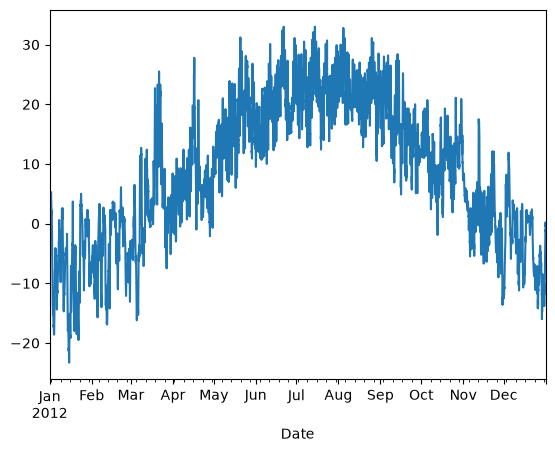

In [5]:
weather.Temp_C.plot()

### Select a subset of the data
We can directly keep the data of a given month or day provided that we use the same format as the index column

<Axes: xlabel='Date'>

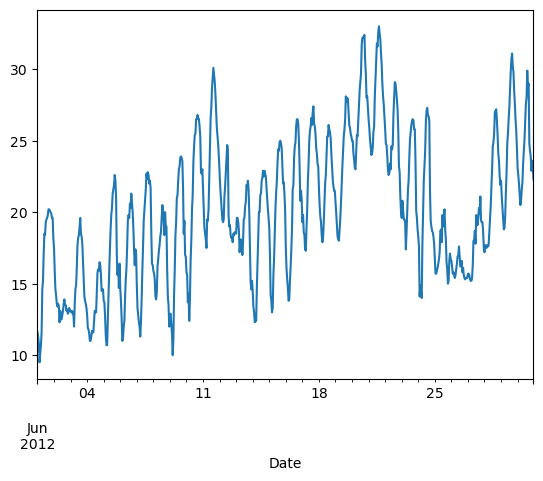

In [8]:
# We can select part of the data via the date.
weather.Temp_C.loc['06-2012'].plot() # By choosing directly a day or mois dd-mm-yyyy, yyyy-mm-dd

### Select a time interval

Text(0.5, 1.0, 'Temperature (C°)')

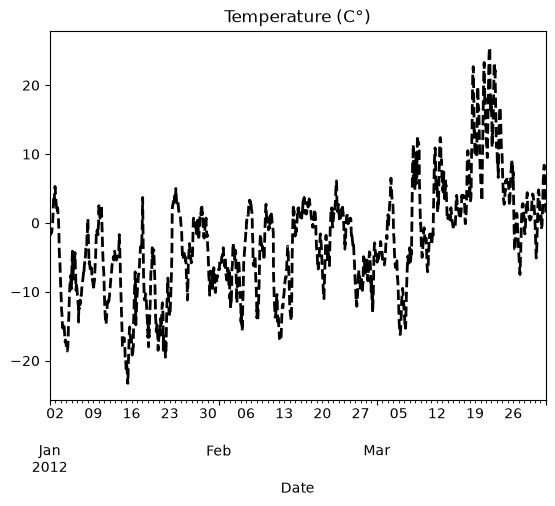

In [6]:
#Similarly to matplolib, we can add options to the plot.
weather.Temp_C.loc['01-2012':'03-2012'].plot(color ='black', linestyle='--', linewidth =2)
plt.title('Temperature (C°)')

# Computing means

### Mean over a given time interval
It is very common to want to plot some mean of our data. The most obvious is to compute daily or monthly means.

- This can directly be done with **.resample('INTERVAL').mean()**
where the time interval can be Day (D) Month (M), Year (Y), Quarter (Q)....

- 'ME' means Month end.

- We can do e.g.g '3D' to group over 3 days frequency etc...

Text(0.5, 1.0, 'Temperatures')

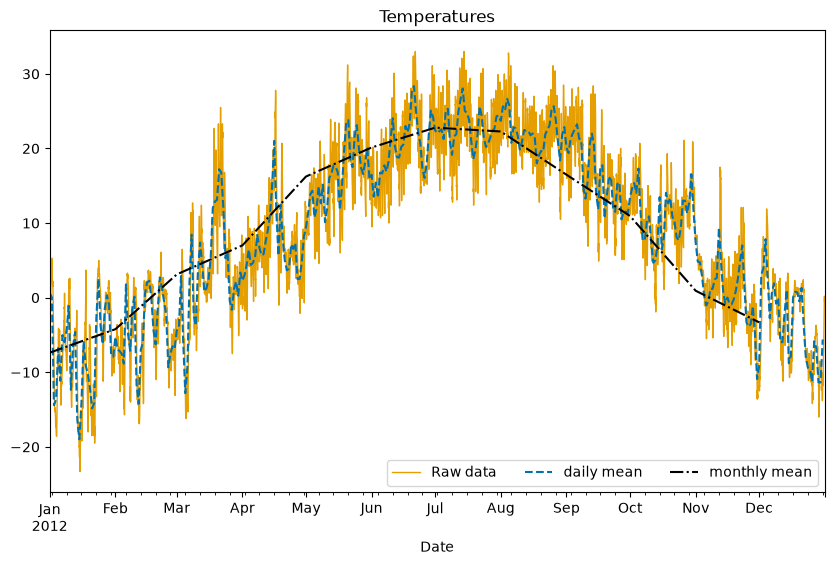

In [8]:
fig = plt.figure(figsize=(10,6))
weather.Temp_C.plot(label='Raw data',linewidth=1, color='#E69F00')
weather.Temp_C.resample('D').mean().plot(label='daily mean', color = '#0072B2',linestyle = '--') 
weather.Temp_C.resample('ME').mean().plot(label='monthly mean', color = '#000000', linestyle = '-.') 
plt.legend(ncol=3)
plt.title('Temperatures')

 Naturally,the longer the time interval, the smoother is the plot

### Rolling mean
A rolling mean keeps the frqeuency of the time series (we end up with as many points as the raw data), but it smooths the signal over the chosen interval

- To compute rolling means, we use **.rolling(Interval, center =True).mean()**

- With a X points interval, for each data point, we compute the mean on the X/2 points of each side.

- We compute the standard deviation on the interval with rolling(Interval, center = True).std()

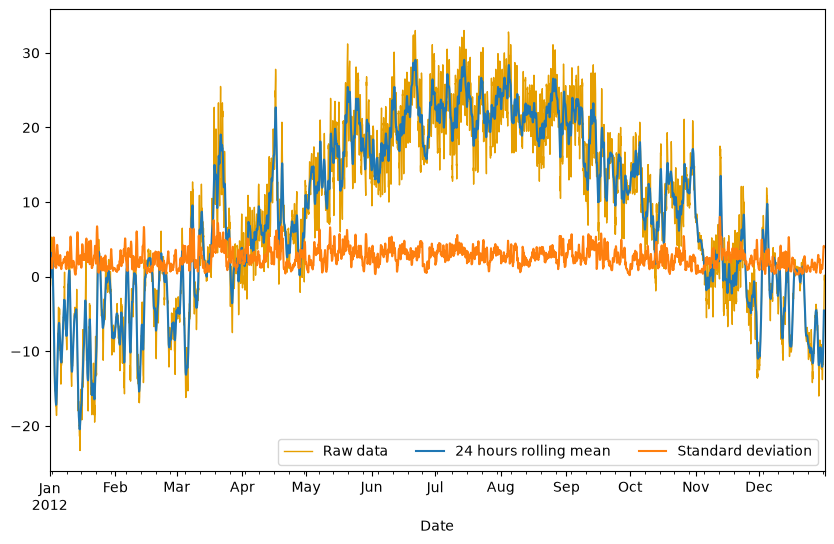

In [16]:
fig = plt.figure(figsize=(10,6))
weather.Temp_C.plot(label='Raw data',linewidth=1, color='#E69F00')
weather.Temp_C.rolling(20,center=True).mean().plot(label ='24 hours rolling mean')
weather.Temp_C.rolling(20,center=True).std().plot(label ='Standard deviation')
plt.legend(ncol=3)

### Climatology daily mean
By computing the average temperature for a given day 
Compute the mean temperature by day of the month, grouped over all the available months

In [17]:
# weather.Temp_C.groupby(weather.index.day).mean().plot(label='Daily mean')
# plt.title('Mean daily mean temperature compiled over the all the months (C°)')